PRACTICAL 02: COMPARATIVE BENCHMARK ANALYSIS OF AI SEARCH PARADIGMS

--- 1. UNINFORMED SEARCH BENCHMARK ---
BFS -> Path: A->C->H->GOAL | Cost: 20 | Nodes: 9 | Time: 0.016 ms
DFS -> Path: A->C->H->GOAL | Cost: 20 | Nodes: 4 | Time: 0.006 ms

--- 2. INFORMED HEURISTIC SEARCH BENCHMARK (8-PUZZLE) ---
A* Search -> Path Depth: 2 | Nodes Expanded: 3 | Time: 0.043 ms
GBFS      -> Path Depth: 2 | Nodes Expanded: 3 | Time: 0.032 ms

--- 3. LOCAL SEARCH BENCHMARK (8-QUEENS) ---
Hill Climbing (Restarts) -> Conflicts: 0 | Restarts: 1 | Time: 2.262 ms
Simulated Annealing      -> Conflicts: 0 | Iterations: 361 | Time: 2.107 ms

--- 4. CSP BENCHMARK (AUSTRALIA MAP 3-COLORING) ---
Solution: WA: Red, NT: Green, SA: Blue, Q: Red, NSW: Green, V: Red, T: Red
Backtracks: 0 | Constraint Checks: 184 | Execution Time: 0.072 ms


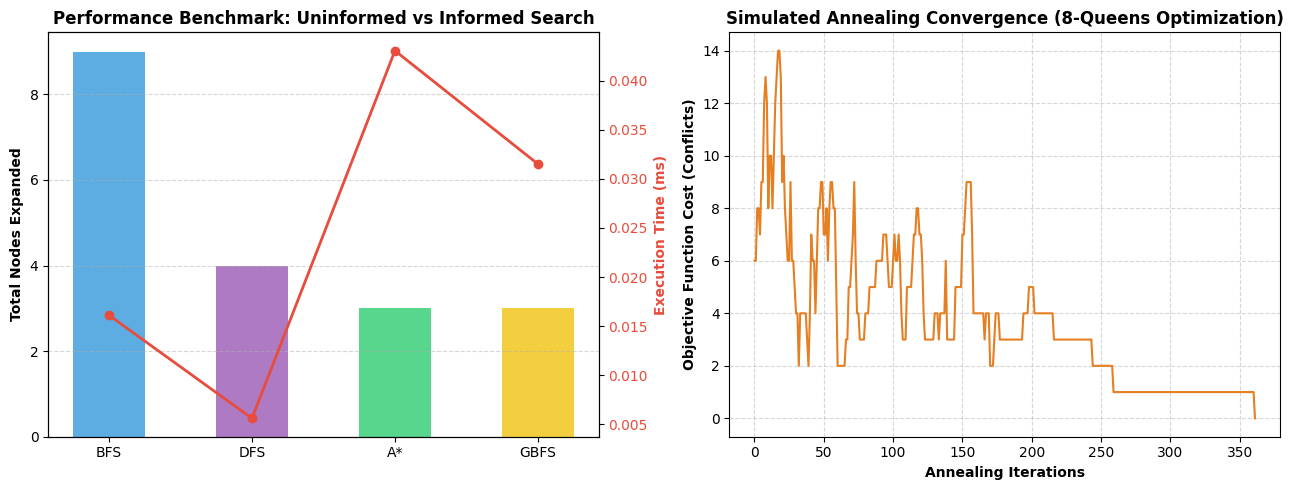

In [1]:
import time
import heapq
import collections
import random
import math
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. UNINFORMED SEARCH (BFS & DFS) - GRAPH NAVIGATION
# ==============================================================================
GRAPH = {
    'A': [('B', 2), ('C', 5)],
    'B': [('D', 4), ('E', 3)],
    'C': [('F', 6), ('H', 8)],
    'D': [],
    'E': [('G', 2)],
    'F': [],
    'G': [('GOAL', 4)],
    'H': [('GOAL', 7)],
    'GOAL': []
}

def bfs(graph, start, goal):
    t0 = time.perf_counter()
    q = collections.deque([(start, [start], 0)])
    visited = set()
    nodes_expanded = 0

    while q:
        curr, path, cost = q.popleft()
        if curr in visited:
            continue
        visited.add(curr)
        nodes_expanded += 1

        if curr == goal:
            dt = (time.perf_counter() - t0) * 1000
            return path, cost, nodes_expanded, dt

        for nbr, w in graph.get(curr, []):
            if nbr not in visited:
                q.append((nbr, path + [nbr], cost + w))
    return None, 0, nodes_expanded, 0.0

def dfs(graph, start, goal):
    t0 = time.perf_counter()
    stack = [(start, [start], 0)]
    visited = set()
    nodes_expanded = 0

    while stack:
        curr, path, cost = stack.pop()
        if curr in visited:
            continue
        visited.add(curr)
        nodes_expanded += 1

        if curr == goal:
            dt = (time.perf_counter() - t0) * 1000
            return path, cost, nodes_expanded, dt

        for nbr, w in graph.get(curr, []):
            if nbr not in visited:
                stack.append((nbr, path + [nbr], cost + w))
    return None, 0, nodes_expanded, 0.0


# ==============================================================================
# 2. INFORMED HEURISTIC SEARCH (A* & GBFS) - 8-PUZZLE
# ==============================================================================
PUZZLE_START = (1, 2, 3, 4, 0, 6, 7, 5, 8)  # 2 moves away from goal
PUZZLE_GOAL  = (1, 2, 3, 4, 5, 6, 7, 8, 0)

def manhattan_distance(state):
    dist = 0
    for idx, val in enumerate(state):
        if val != 0:
            target_idx = val - 1
            r1, c1 = divmod(idx, 3)
            r2, c2 = divmod(target_idx, 3)
            dist += abs(r1 - r2) + abs(c1 - c2)
    return dist

def get_neighbors(state):
    neighbors = []
    zero_idx = state.index(0)
    r, c = divmod(zero_idx, 3)
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for dr, dc in moves:
        nr, nc = r + dr, c + dc
        if 0 <= nr < 3 and 0 <= nc < 3:
            nxt_idx = nr * 3 + nc
            new_state = list(state)
            new_state[zero_idx], new_state[nxt_idx] = new_state[nxt_idx], new_state[zero_idx]
            neighbors.append(tuple(new_state))
    return neighbors

def astar(start, goal, h_func):
    t0 = time.perf_counter()
    pq = [(h_func(start), 0, start, [start])]
    visited = {}
    nodes_expanded = 0

    while pq:
        f, g, curr, path = heapq.heappop(pq)
        if curr in visited and visited[curr] <= g:
            continue
        visited[curr] = g
        nodes_expanded += 1

        if curr == goal:
            dt = (time.perf_counter() - t0) * 1000
            return path, g, nodes_expanded, dt

        for nxt in get_neighbors(curr):
            heapq.heappush(pq, (g + 1 + h_func(nxt), g + 1, nxt, path + [nxt]))
    return None, 0, nodes_expanded, 0.0

def gbfs(start, goal, h_func):
    t0 = time.perf_counter()
    pq = [(h_func(start), 0, start, [start])]
    visited = set()
    nodes_expanded = 0

    while pq:
        h, g, curr, path = heapq.heappop(pq)
        if curr in visited:
            continue
        visited.add(curr)
        nodes_expanded += 1

        if curr == goal:
            dt = (time.perf_counter() - t0) * 1000
            return path, g, nodes_expanded, dt

        for nxt in get_neighbors(curr):
            if nxt not in visited:
                heapq.heappush(pq, (h_func(nxt), g + 1, nxt, path + [nxt]))
    return None, 0, nodes_expanded, 0.0


# ==============================================================================
# 3. LOCAL SEARCH (HILL CLIMBING & SIMULATED ANNEALING) - 8-QUEENS
# ==============================================================================
def count_conflicts(board):
    conflicts = 0
    n = len(board)
    for i in range(n):
        for j in range(i + 1, n):
            if board[i] == board[j] or abs(board[i] - board[j]) == abs(i - j):
                conflicts += 1
    return conflicts

def hill_climbing_restarts(n=8, max_restarts=50):
    random.seed(42)
    t0 = time.perf_counter()
    restarts = 0

    while restarts < max_restarts:
        board = [random.randint(0, n - 1) for _ in range(n)]
        curr_conflicts = count_conflicts(board)

        while True:
            if curr_conflicts == 0:
                dt = (time.perf_counter() - t0) * 1000
                return board, curr_conflicts, restarts, dt

            best_board = list(board)
            best_conflicts = curr_conflicts

            for col in range(n):
                for row in range(n):
                    if board[col] == row:
                        continue
                    candidate = list(board)
                    candidate[col] = row
                    c = count_conflicts(candidate)
                    if c < best_conflicts:
                        best_conflicts = c
                        best_board = candidate

            if best_conflicts >= curr_conflicts:
                break
            board = best_board
            curr_conflicts = best_conflicts

        restarts += 1

    dt = (time.perf_counter() - t0) * 1000
    return board, curr_conflicts, restarts, dt

def simulated_annealing(n=8, max_iter=600):
    random.seed(7)
    t0 = time.perf_counter()
    board = [random.randint(0, n - 1) for _ in range(n)]
    curr_conflicts = count_conflicts(board)
    T = 10.0
    cooling_rate = 0.985
    history = [curr_conflicts]

    for step in range(1, max_iter + 1):
        if curr_conflicts == 0:
            break
        col = random.randint(0, n - 1)
        new_row = random.randint(0, n - 1)
        candidate = list(board)
        candidate[col] = new_row
        next_conflicts = count_conflicts(candidate)
        delta = next_conflicts - curr_conflicts

        if delta < 0 or random.random() < math.exp(-delta / max(T, 1e-5)):
            board = candidate
            curr_conflicts = next_conflicts

        T *= cooling_rate
        history.append(curr_conflicts)

    dt = (time.perf_counter() - t0) * 1000
    return board, curr_conflicts, len(history) - 1, dt, history


# ==============================================================================
# 4. CONSTRAINT SATISFACTION PROBLEM (CSP: BACKTRACKING + MRV)
# ==============================================================================
AUSTRALIA_CSP = {
    'WA':  ['NT', 'SA'],
    'NT':  ['WA', 'SA', 'Q'],
    'SA':  ['WA', 'NT', 'Q', 'NSW', 'V'],
    'Q':   ['NT', 'SA', 'NSW'],
    'NSW': ['Q', 'SA', 'V'],
    'V':   ['SA', 'NSW'],
    'T':   []
}
COLORS = ['Red', 'Green', 'Blue']

def solve_csp_mrv(neighbors_map, domains):
    t0 = time.perf_counter()
    assignment = {}
    stats = {'backtracks': 0, 'checks': 0}

    def is_consistent(var, val):
        for nbr in neighbors_map[var]:
            stats['checks'] += 1
            if nbr in assignment and assignment[nbr] == val:
                return False
        return True

    def select_unassigned_mrv():
        unassigned = [v for v in neighbors_map if v not in assignment]
        return min(unassigned, key=lambda var: sum(1 for c in domains[var] if is_consistent(var, c)))

    def backtrack():
        if len(assignment) == len(neighbors_map):
            return True
        var = select_unassigned_mrv()
        for val in domains[var]:
            if is_consistent(var, val):
                assignment[var] = val
                if backtrack():
                    return True
                del assignment[var]
        stats['backtracks'] += 1
        return False

    backtrack()
    dt = (time.perf_counter() - t0) * 1000
    return assignment, stats['backtracks'], stats['checks'], dt


# ==============================================================================
# MAIN EXECUTION & PLOTTING
# ==============================================================================
if __name__ == "__main__":
    # Run Benchmarks
    bfs_path, bfs_cost, bfs_nodes, bfs_time = bfs(GRAPH, 'A', 'GOAL')
    dfs_path, dfs_cost, dfs_nodes, dfs_time = dfs(GRAPH, 'A', 'GOAL')

    astar_path, astar_depth, astar_nodes, astar_time = astar(PUZZLE_START, PUZZLE_GOAL, manhattan_distance)
    gbfs_path, gbfs_depth, gbfs_nodes, gbfs_time = gbfs(PUZZLE_START, PUZZLE_GOAL, manhattan_distance)

    hc_board, hc_conf, hc_restarts, hc_time = hill_climbing_restarts()
    sa_board, sa_conf, sa_iters, sa_time, sa_history = simulated_annealing()

    domains = {v: list(COLORS) for v in AUSTRALIA_CSP}
    csp_sol, csp_bt, csp_checks, csp_time = solve_csp_mrv(AUSTRALIA_CSP, domains)

    # Print Formatted Terminal Output
    print("=" * 75)
    print("PRACTICAL 02: COMPARATIVE BENCHMARK ANALYSIS OF AI SEARCH PARADIGMS")
    print("=" * 75)

    print("\n--- 1. UNINFORMED SEARCH BENCHMARK ---")
    print(f"BFS -> Path: {'->'.join(bfs_path)} | Cost: {bfs_cost} | Nodes: {bfs_nodes} | Time: {bfs_time:.3f} ms")
    print(f"DFS -> Path: {'->'.join(dfs_path)} | Cost: {dfs_cost} | Nodes: {dfs_nodes} | Time: {dfs_time:.3f} ms")

    print("\n--- 2. INFORMED HEURISTIC SEARCH BENCHMARK (8-PUZZLE) ---")
    print(f"A* Search -> Path Depth: {astar_depth} | Nodes Expanded: {astar_nodes} | Time: {astar_time:.3f} ms")
    print(f"GBFS      -> Path Depth: {gbfs_depth} | Nodes Expanded: {gbfs_nodes} | Time: {gbfs_time:.3f} ms")

    print("\n--- 3. LOCAL SEARCH BENCHMARK (8-QUEENS) ---")
    print(f"Hill Climbing (Restarts) -> Conflicts: {hc_conf} | Restarts: {hc_restarts} | Time: {hc_time:.3f} ms")
    print(f"Simulated Annealing      -> Conflicts: {sa_conf} | Iterations: {sa_iters} | Time: {sa_time:.3f} ms")

    print("\n--- 4. CSP BENCHMARK (AUSTRALIA MAP 3-COLORING) ---")
    ordered_vars = ['WA', 'NT', 'SA', 'Q', 'NSW', 'V', 'T']
    sol_str = ", ".join(f"{k}: {csp_sol[k]}" for k in ordered_vars)
    print(f"Solution: {sol_str}")
    print(f"Backtracks: {csp_bt} | Constraint Checks: {csp_checks} | Execution Time: {csp_time:.3f} ms")
    print("=" * 75)

    # Generate Benchmark Visualizations
    fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(13, 5))

    # Plot 1: Uninformed vs Informed Search
    algos = ['BFS', 'DFS', 'A*', 'GBFS']
    nodes_list = [bfs_nodes, dfs_nodes, astar_nodes, gbfs_nodes]
    times_list = [bfs_time, dfs_time, astar_time, gbfs_time]

    bars = ax1.bar(algos, nodes_list, color=['#3498db', '#9b59b6', '#2ecc71', '#f1c40f'], alpha=0.8, width=0.5)
    ax1.set_ylabel('Total Nodes Expanded', fontweight='bold')
    ax1.set_title('Performance Benchmark: Uninformed vs Informed Search', fontweight='bold')
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

    ax2 = ax1.twinx()
    ax2.plot(algos, times_list, color='#e74c3c', marker='o', linewidth=2, label='Execution Time (ms)')
    ax2.set_ylabel('Execution Time (ms)', color='#e74c3c', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='#e74c3c')

    # Plot 2: Simulated Annealing Convergence
    ax3.plot(sa_history, color='#e67e22', linewidth=1.5)
    ax3.set_title('Simulated Annealing Convergence (8-Queens Optimization)', fontweight='bold')
    ax3.set_xlabel('Annealing Iterations', fontweight='bold')
    ax3.set_ylabel('Objective Function Cost (Conflicts)', fontweight='bold')
    ax3.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()